Necessary Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import wavfile
from scipy.fftpack import fft

FFT Magnitude function which will be used a lot later

In [2]:
def compute_fft(segment):
    spectrum = fft(segment)
    spectrum = spectrum[0:len(segment)//2]
    magnitude = np.abs(spectrum)
    return magnitude


Reading the .wav file and converting it to mono if stereo

In [3]:
fs, signal = wavfile.read("audio.wav")
if len(signal.shape) > 1:
    signal = signal.mean(axis=1)
signal = signal.astype(float)
print("Sampling Frequency =", fs, "Hz")
print("Length of Full Signal =", len(signal), "samples")
print("Signal Duration =", len(signal)/fs, "seconds")


Sampling Frequency = 44100 Hz
Length of Full Signal = 422784 samples
Signal Duration = 9.586938775510204 seconds


This Cell plots the whole audio in the time domain

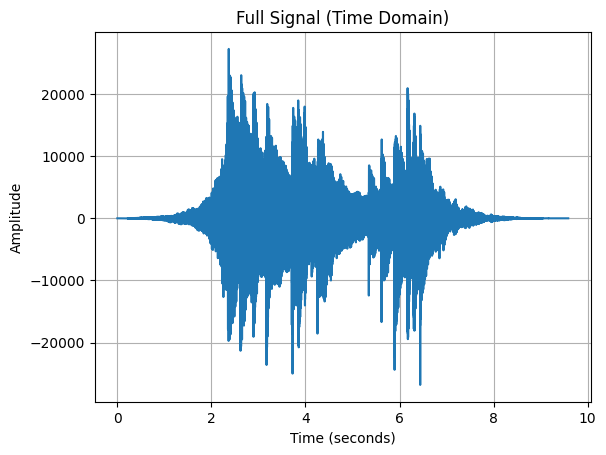

In [4]:
time = np.arange(len(signal)) / fs
plt.plot(time, signal)
plt.title("Full Signal (Time Domain)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

Taking a clip from the full audio from 3s to 5s

In [5]:
start = 5
duration = 3
start_index = int(start * fs)
end_index = int((start + duration) * fs)
clip = signal[start_index:end_index]
print("Clip Length =", len(clip), "samples")
print("Original Clip Position =", start, "seconds")

Clip Length = 132300 samples
Original Clip Position = 5 seconds


Plotting the clip in time domain

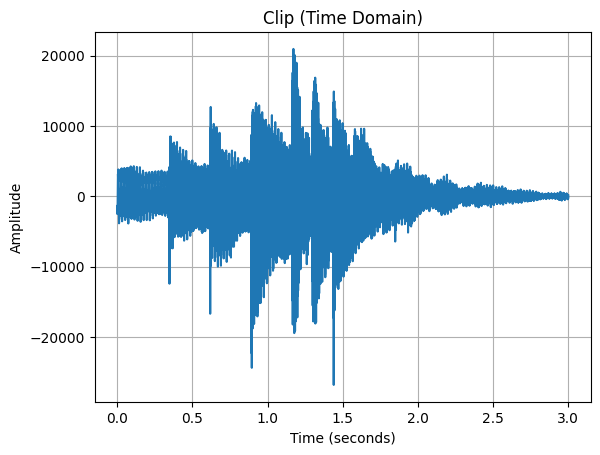

In [6]:
clip_time = np.arange(len(clip)) / fs
plt.plot(clip_time, clip)
plt.title("Clip (Time Domain)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

Plotting Clip in frequency domain with only the positive side since fft gives an even plot with positive and negative frequecies but we only take the positive.

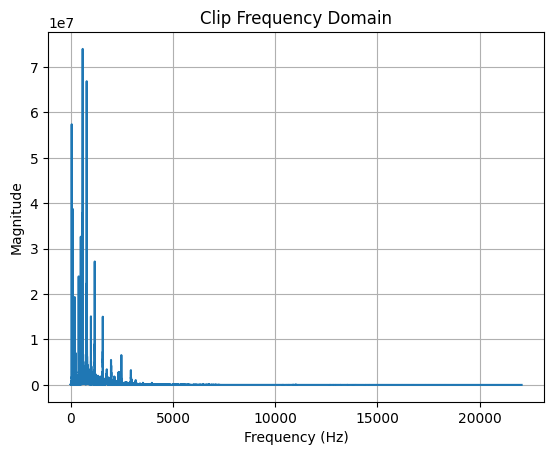

In [7]:
clip_fft = compute_fft(clip)
frequencies = np.linspace(0, fs/2, len(clip_fft))
plt.plot(frequencies, clip_fft)
plt.title("Clip Frequency Domain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid()
plt.show()

This is the main code where we slide over the original audio using the sliding window algorithm and compare  the fft of each segment with the original clip's fft and we normalize to finally compute a score that indicates how similar the segment and the clip are and we add in the similarity_scores array. We add the time of the current segment in the positions array.

In [8]:
window_length = len(clip)
step_size = 1000
similarity_scores = []
positions = []
for i in range(0, len(signal) - window_length, step_size):
    segment = signal[i:i + window_length]
    segment_fft = compute_fft(segment)
    numerator = np.dot(clip_fft, segment_fft)
    denominator = (
        np.linalg.norm(clip_fft)
        * np.linalg.norm(segment_fft)
    )
    similarity = numerator / denominator
    similarity_scores.append(similarity)
    positions.append(i / fs)

best_index = np.argmax(similarity_scores)
detected_time = positions[best_index]
best_score = similarity_scores[best_index]

print("Detected Position =", detected_time, "seconds")
print("Best Similarity Score =", best_score)

Detected Position = 5.011337868480726 seconds
Best Similarity Score = 0.9998452845155616


We compute here the highest similarity score and its position and print them.

In [9]:
best_index = np.argmax(similarity_scores)
detected_time = positions[best_index]
best_score = similarity_scores[best_index]

print("Detected Position =", detected_time, "seconds")
print("Best Similarity Score =", best_score)

Detected Position = 5.011337868480726 seconds
Best Similarity Score = 0.9998452845155616


We plot here the similarity scores against time. The starting time of each sample vs the similarity score of the corresponding sample.

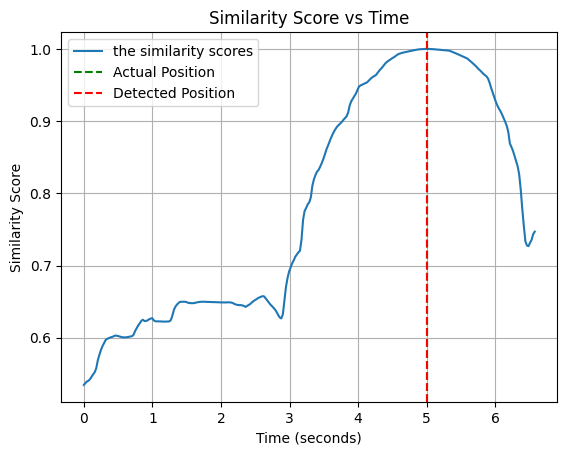

In [10]:
plt.plot(positions, similarity_scores, label='the similarity scores')
plt.axvline(start, color='green', linestyle='--', label='Actual Position')
#the above to highlight where the clip actually starts.
plt.axvline(detected_time, color='red', linestyle='--', label='Detected Position')
#the above to highlight the detected time of where clip starts.
plt.title("Similarity Score vs Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Similarity Score")
plt.legend()
plt.grid()
plt.show()

Finally we find the best segment and plot it against time and in the same figure the plot the original clip to see how close they are in time domain.

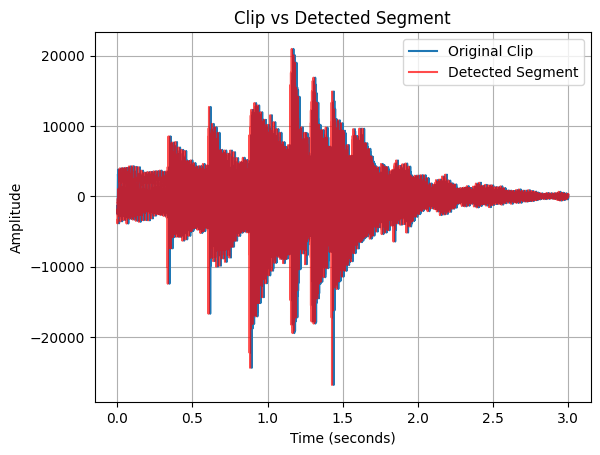

In [11]:
detected_index = int(detected_time * fs)
detected_segment = signal[
    detected_index : detected_index + window_length
]

plt.plot(clip_time, clip, label="Original Clip")
plt.plot(clip_time, detected_segment, label="Detected Segment", color='red', alpha=0.7)
plt.title("Clip vs Detected Segment")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.legend()
plt.grid()

plt.show()